# Day 4: 决策树（CART）— Iris 分类

用 numpy 实现 CART 决策树（分类），在 Iris 数据集上训练、评估、可视化。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import sys, os
sys.path.append(os.path.abspath('..'))
from models.decision_tree import DecisionTree

plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
from sklearn.datasets import load_iris
iris = load_iris()
X, y, feature_names, target_names = iris.data, iris.target, iris.feature_names, iris.target_names

print(f'样本数: {X.shape[0]}, 特征数: {X.shape[1]}')
print(f'类别: {target_names}')
print(f'特征: {feature_names}')
df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y]
df.head()

样本数: 150, 特征数: 4
类别: ['setosa' 'versicolor' 'virginica']
特征: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
print(df.groupby('species').describe().round(2))

           sepal length (cm)                                        \
                       count  mean   std  min   25%  50%  75%  max   
species                                                              
setosa                  50.0  5.01  0.35  4.3  4.80  5.0  5.2  5.8   
versicolor              50.0  5.94  0.52  4.9  5.60  5.9  6.3  7.0   
virginica               50.0  6.59  0.64  4.9  6.22  6.5  6.9  7.9   

           sepal width (cm)        ... petal length (cm)       \
                      count  mean  ...               75%  max   
species                            ...                          
setosa                 50.0  3.43  ...              1.58  1.9   
versicolor             50.0  2.77  ...              4.60  5.1   
virginica              50.0  2.97  ...              5.88  6.9   

           petal width (cm)                                       
                      count  mean   std  min  25%  50%  75%  max  
species                                               

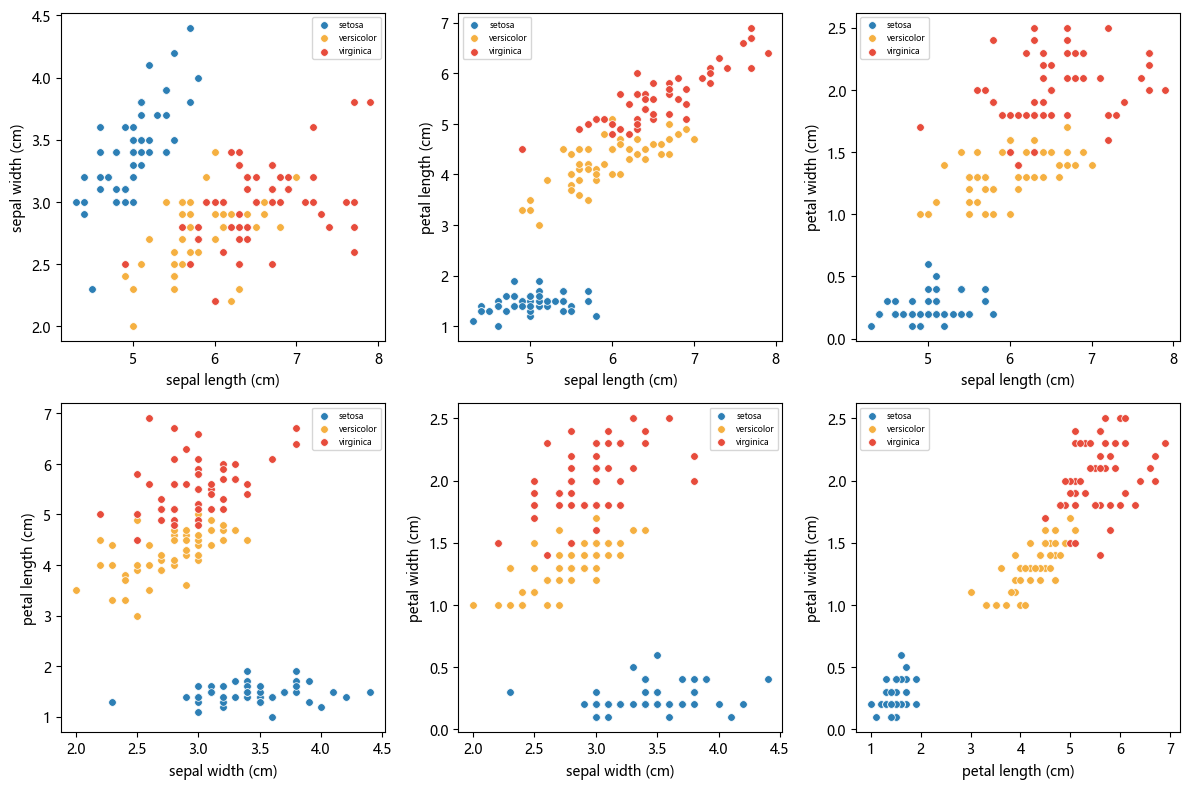

In [4]:
# 快速可视化：两两特征散点
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
pairs = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]
colors = ['#2d7fb5', '#f5b041', '#e74c3c']
for axx, (i, j) in zip(axes.flat, pairs):
    for cls in range(3):
        axx.scatter(X[y==cls, i], X[y==cls, j],
                   c=colors[cls], label=target_names[cls],
                   edgecolors='white', linewidth=0.5, s=30)
    axx.set_xlabel(feature_names[i])
    axx.set_ylabel(feature_names[j])
    axx.legend(fontsize=6)
plt.tight_layout()
plt.savefig('../articles/ml/day4_pairplot.png', dpi=200, bbox_inches='tight')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f'训练集: {X_train.shape[0]}, 测试集: {X_test.shape[0]}')

训练集: 120, 测试集: 30


In [6]:
# 训练决策树
dt = DecisionTree(max_depth=3)
dt.fit(X_train, y_train)

train_pred = dt.predict(X_train)
test_pred = dt.predict(X_test)
train_acc = np.mean(train_pred == y_train)
test_acc = np.mean(test_pred == y_test)
print(f'训练集准确率: {train_acc:.4f}')
print(f'测试集准确率: {test_acc:.4f}')

训练集准确率: 0.9583
测试集准确率: 1.0000


In [7]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, test_pred)
print('混淆矩阵:')
print(cm)
print()
print(classification_report(y_test, test_pred, target_names=target_names))

混淆矩阵:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



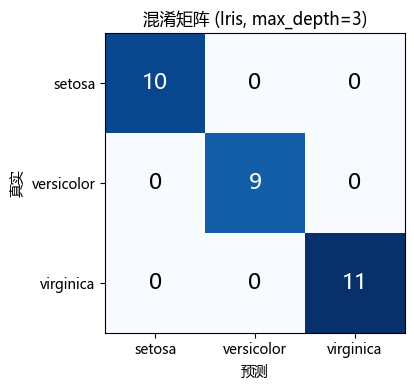

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(target_names)
ax.set_yticklabels(target_names)
ax.set_xlabel('预测')
ax.set_ylabel('真实')
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                fontsize=16, color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.title('混淆矩阵 (Iris, max_depth=3)')
plt.tight_layout()
plt.savefig('../articles/ml/day4_cm.png', dpi=200, bbox_inches='tight')
plt.show()

In [9]:
print('决策树结构 (max_depth=3):')
dt.print_tree()

决策树结构 (max_depth=3):
[特征 2 <= 2.45]
  ├─ 左分支:
  │ → 类别 0  (样本分布: [40  0  0])
  └─ 右分支:
    [特征 2 <= 4.75]
      ├─ 左分支:
      │ [特征 3 <= 1.65]
      │   ├─ 左分支:
      │   │ → 类别 1  (样本分布: [ 0 36  0])
      │   └─ 右分支:
      │     → 类别 2  (样本分布: [0 0 1])
      └─ 右分支:
        [特征 3 <= 1.75]
          ├─ 左分支:
          │ → 类别 1  (样本分布: [0 4 4])
          └─ 右分支:
            → 类别 2  (样本分布: [ 0  1 34])


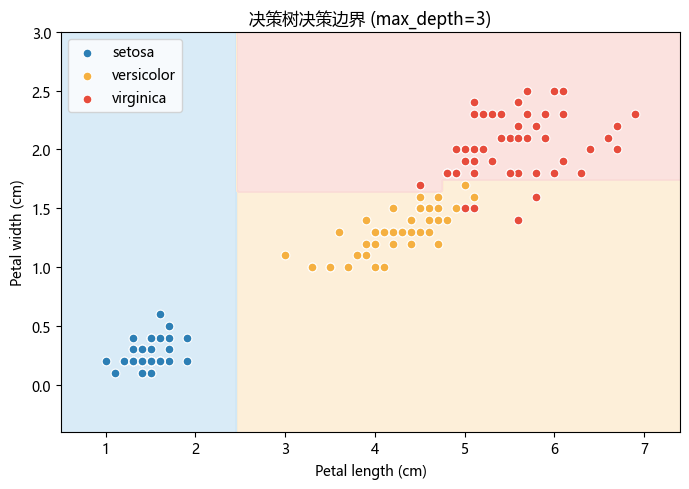

In [10]:
# 决策边界可视化 (取 petal length 和 petal width 两个特征)
X2 = X[:, [2, 3]]
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42)
dt2 = DecisionTree(max_depth=3)
dt2.fit(X2_train, y2_train)

x_min, x_max = X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5
y_min, y_max = X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = dt2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 5))
cmap_light = ListedColormap(['#d0e6f5', '#fdebd0', '#fadbd8'])
cmap_bold  = ['#2d7fb5', '#f5b041', '#e74c3c']
ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
for cls in range(3):
    ax.scatter(X2[y==cls, 0], X2[y==cls, 1],
               c=cmap_bold[cls], label=target_names[cls],
               edgecolors='white', linewidth=0.8, s=40)
ax.set_xlabel('Petal length (cm)')
ax.set_ylabel('Petal width (cm)')
ax.set_title('决策树决策边界 (max_depth=3)')
ax.legend()
plt.tight_layout()
plt.savefig('../articles/ml/day4_boundary.png', dpi=200, bbox_inches='tight')
plt.show()

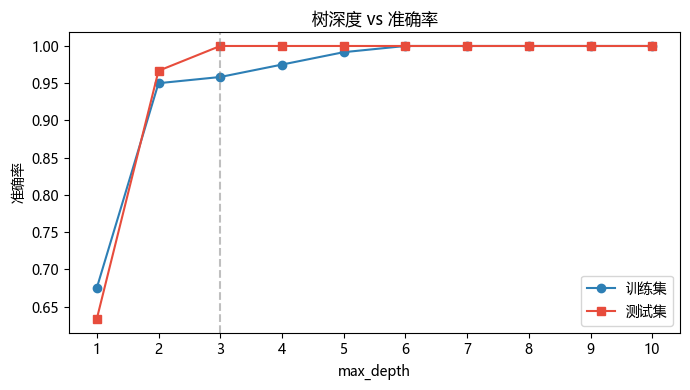

In [11]:
# 超参数扫描：max_depth
depths = range(1, 11)
train_scores, test_scores = [], []
for d in depths:
    m = DecisionTree(max_depth=d)
    m.fit(X_train, y_train)
    train_scores.append(np.mean(m.predict(X_train) == y_train))
    test_scores.append(np.mean(m.predict(X_test) == y_test))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depths, train_scores, 'o-', label='训练集', color='#2d7fb5')
ax.plot(depths, test_scores, 's-', label='测试集', color='#e74c3c')
ax.axvline(3, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('max_depth')
ax.set_ylabel('准确率')
ax.set_title('树深度 vs 准确率')
ax.legend()
ax.set_xticks(depths)
plt.tight_layout()
plt.savefig('../articles/ml/day4_depth_scan.png', dpi=200, bbox_inches='tight')
plt.show()

In [12]:
print('深度 | 训练准确率 | 测试准确率')
print('-' * 35)
for d, tr, te in zip(depths, train_scores, test_scores):
    print(f'  {d:2d}  |   {tr:.4f}    |   {te:.4f}')

深度 | 训练准确率 | 测试准确率
-----------------------------------
   1  |   0.6750    |   0.6333
   2  |   0.9500    |   0.9667
   3  |   0.9583    |   1.0000
   4  |   0.9750    |   1.0000
   5  |   0.9917    |   1.0000
   6  |   1.0000    |   1.0000
   7  |   1.0000    |   1.0000
   8  |   1.0000    |   1.0000
   9  |   1.0000    |   1.0000
  10  |   1.0000    |   1.0000


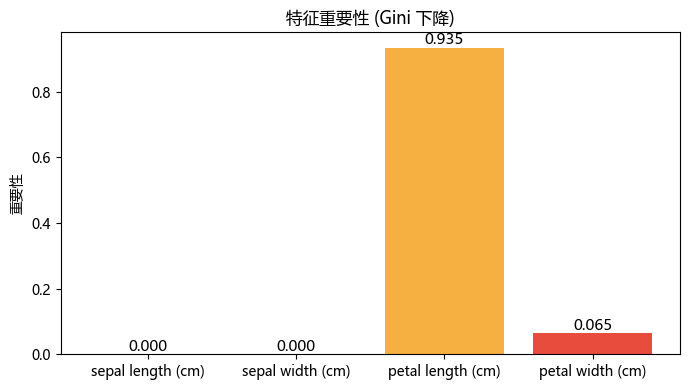

In [13]:
# 特征重要性
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(feature_names, dt.feature_importances_,
       color=['#2d7fb5', '#76b7e0', '#f5b041', '#e74c3c'])
ax.set_ylabel('重要性')
ax.set_title('特征重要性 (Gini 下降)')
for i, v in enumerate(dt.feature_importances_):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../articles/ml/day4_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()

In [14]:
# 概率输出示例
probas = dt.predict_proba(X_test[:5])
print('前 5 个测试样本的类别概率:')
for i, p in enumerate(probas):
    pred = np.argmax(p)
    true = y_test[i]
    print(f'样本 {i+1}: 真实={target_names[true]}, '
          f'预测={target_names[pred]}, '
          f'概率=[setosa={p[0]:.3f}, versicolor={p[1]:.3f}, virginica={p[2]:.3f}]')

前 5 个测试样本的类别概率:
样本 1: 真实=versicolor, 预测=versicolor, 概率=[setosa=0.000, versicolor=1.000, virginica=0.000]
样本 2: 真实=setosa, 预测=setosa, 概率=[setosa=1.000, versicolor=0.000, virginica=0.000]
样本 3: 真实=virginica, 预测=virginica, 概率=[setosa=0.000, versicolor=0.029, virginica=0.971]
样本 4: 真实=versicolor, 预测=versicolor, 概率=[setosa=0.000, versicolor=1.000, virginica=0.000]
样本 5: 真实=versicolor, 预测=versicolor, 概率=[setosa=0.000, versicolor=0.500, virginica=0.500]


In [15]:
# 与 sklearn 对比
from sklearn.tree import DecisionTreeClassifier
sk_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
sk_dt.fit(X_train, y_train)
sk_pred = sk_dt.predict(X_test)
sk_acc = np.mean(sk_pred == y_test)
print(f'sklearn 测试准确率: {sk_acc:.4f}')
print(f'我们的实现测试准确率: {test_acc:.4f}')
print(f'一致: {np.mean(test_pred == sk_pred):.4f}')

sklearn 测试准确率: 1.0000
我们的实现测试准确率: 1.0000
一致: 1.0000


## 公众号文章用图

下面生成最终对比表。

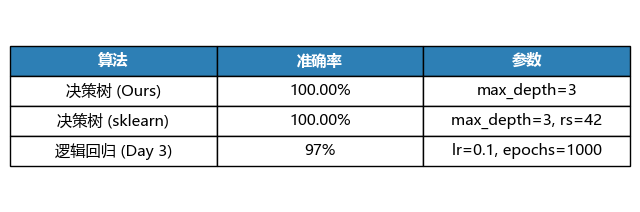

In [16]:
# 公众号对比表
# 用 matplotlib 画表格
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axis('off')

table_data = [
    ['算法', '准确率', '参数'],
    ['决策树 (Ours)', f'{test_acc:.2%}', 'max_depth=3'],
    ['决策树 (sklearn)', f'{sk_acc:.2%}', 'max_depth=3, rs=42'],
    ['逻辑回归 (Day 3)', '97%', 'lr=0.1, epochs=1000'],
]

table = ax.table(cellText=table_data, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)
for key, cell in table.get_celld().items():
    if key[0] == 0:
        cell.set_facecolor('#2d7fb5')
        cell.set_text_props(color='white', fontweight='bold')
plt.savefig('../articles/ml/day4_comparison.png', dpi=200, bbox_inches='tight')
plt.show()